## Classifying Interaction Rank (Dominant vs Subordinate)

In [60]:
# --- Core Python ---
import os
import sys
from pathlib import Path
import h5py
import re

# Ensure notebook-local helper modules are importable
_NB_DIR = Path.cwd()
print(f"currently in {_NB_DIR}")
if (_NB_DIR / "resp_helper_functions.py").exists():
    print("helper functions exists in working directory, adding to sys.path")
    sys.path.insert(0, str(_NB_DIR))
else:
    # Fallback when notebook is launched from workspace root
    _NB_DIR = Path("notebooks/thomas_notebooks/resp_classification").resolve()
    if (_NB_DIR / "resp_helper_functions.py").exists():
        sys.path.insert(0, str(_NB_DIR))
    print("Helper functions didn't exist in working directory, resolving and adding to sys.path")

# --- Numerical & data analysis ---
import numpy as np
import pandas as pd

# --- Plotting ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Signal processing ---
from scipy.signal import butter, filtfilt, resample_poly, find_peaks

# --- Statistics ---
from scipy.stats import wilcoxon

# --- Machine learning & metrics ---
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, GroupKFold, LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.model_selection import StratifiedGroupKFold

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False

# --- Specialized neurophysiology tools ---
import neurokit2 as nk

# All the functions used to load, clean, and verify respiration and BORIS data
from resp_helper_functions import *

# --- Pandas display settings ---
pd.set_option("display.max_rows", 50)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 1000)

currently in c:\Users\thoma\Code\ResearchCode\respiratory_pilot
Helper functions didn't exist in working directory, resolving and adding to sys.path


In [61]:
DATA_DIR = Path(r"C:\Users\thoma\Code\ResearchCode\respiratory_pilot\notebooks\thomas_notebooks\resp_classification\data")

# Load raw feature matrix only — no inline z-score / ratio backfill (that hurt baseline performance)
feature_matrix = pd.read_pickle(DATA_DIR / "Raw-Breathmatrics-Features-Rank")

ONSET2S_PATH = DATA_DIR / "Raw-Breathmatrics-Features-Rank-onset2s"
feature_matrix_onset2s = pd.read_pickle(ONSET2S_PATH) if ONSET2S_PATH.exists() else None
RESP_PATHS_PATH = DATA_DIR / "resp_paths_interactions_rank.pkl"
resp_paths_lookup = pd.read_pickle(RESP_PATHS_PATH) if RESP_PATHS_PATH.exists() else {}

feature_matrix.columns

Index(['Behavior', 'Start', 'Stop', 'Duration', 'PreBoutRespRate', 'Trial', 'Subject', 'Condition', 'Rank', 'Type', 'Label', 'n_breaths', 'breathing_rate_hz', 'mean_ibi_sec', 'cv_ibi', 'mean_inhale_dur_sec', 'cv_inhale_dur', 'mean_exhale_dur_sec', 'cv_exhale_dur', 'ie_ratio', 'mean_peak_insp_flow', 'mean_peak_exp_flow', 'cv_peak_insp_flow', 'mean_inhale_vol', 'mean_exhale_vol', 'mean_tidal_vol_proxy', 'cv_inhale_vol', 'ventilation_proxy', 'pct_breaths_with_inhale_pause', 'mean_inhale_pause_dur_sec', 'cv_inhale_pause_dur', 'inhale_pause_duty_cycle', 'pct_breaths_with_exhale_pause', 'mean_exhale_pause_dur_sec', 'cv_exhale_pause_dur', 'exhale_pause_duty_cycle', 'inhale_duty_cycle', 'exhale_duty_cycle', 'resp_rate_delta', 'breathing_rate_z'], dtype='object')

In [62]:
feature_matrix.head()

,Behavior,Start,Stop,Duration,PreBoutRespRate,Trial,Subject,Condition,Rank,Type,Label,n_breaths,breathing_rate_hz,mean_ibi_sec,cv_ibi,mean_inhale_dur_sec,cv_inhale_dur,mean_exhale_dur_sec,cv_exhale_dur,ie_ratio,mean_peak_insp_flow,mean_peak_exp_flow,cv_peak_insp_flow,mean_inhale_vol,mean_exhale_vol,mean_tidal_vol_proxy,cv_inhale_vol,ventilation_proxy,pct_breaths_with_inhale_pause,mean_inhale_pause_dur_sec,cv_inhale_pause_dur,inhale_pause_duty_cycle,pct_breaths_with_exhale_pause,mean_exhale_pause_dur_sec,cv_exhale_pause_dur,exhale_pause_duty_cycle,inhale_duty_cycle,exhale_duty_cycle,resp_rate_delta,breathing_rate_z
0,facial sniffing,10.9830,13.9830,3.0,6.869221,RI1_3_6,3_6,RI1,Dominant,Interaction,NaN,31,10.647737,0.093917,0.141639,0.044032,0.349303,0.047742,0.297815,0.922297,1443.020432,-1261.673197,0.306335,45797.370015,41282.725135,87080.095149,0.451884,927205.982069,0.0,0.0,NaN,0.0,0.0,0.0,NaN,0.0,0.468844,0.508344,3.778517,1.427727
1,anogenital sniffing,14.0865,17.0865,3.0,9.921671,RI1_3_6,3_6,RI1,Dominant,Interaction,NaN,30,9.822185,0.101810,0.302527,0.044833,0.387117,0.051417,0.522124,0.871961,1326.573540,-996.957219,0.364073,42480.201046,35615.332067,78095.533113,0.499278,767068.741839,0.0,0.0,NaN,0.0,0.0,0.0,NaN,0.0,0.440361,0.505024,-0.099486,0.719983
2,anogenital sniffing,24.7930,27.7930,3.0,9.656925,RI1_3_6,3_6,RI1,Dominant,Interaction,NaN,28,9.375000,0.106667,0.263935,0.047321,0.455980,0.053929,0.271564,0.877483,1270.002939,-997.226511,0.295554,40989.318523,37360.077920,78349.396443,0.468705,734525.591653,0.0,0.0,NaN,0.0,0.0,0.0,NaN,0.0,0.443638,0.505580,-0.281925,0.336612
3,body sniffing,26.6205,29.6205,3.0,9.781210,RI1_3_6,3_6,RI1,Dominant,Interaction,NaN,27,9.203540,0.108654,0.272187,0.046296,0.473362,0.056574,0.338927,0.818331,1115.364123,-978.871961,0.259686,35563.725434,38020.301134,73584.026568,0.487733,677233.518856,0.0,0.0,NaN,0.0,0.0,0.0,NaN,0.0,0.426090,0.520682,-0.577670,0.189620
4,anogenital sniffing,27.8615,30.8615,3.0,9.411765,RI1_3_6,3_6,RI1,Dominant,Interaction,NaN,28,9.574468,0.104444,0.174846,0.043393,0.137906,0.056250,0.317952,0.771429,1188.448729,-989.114420,0.269907,36678.249475,37672.323340,74350.572815,0.372353,711867.186529,0.0,0.0,NaN,0.0,0.0,0.0,NaN,0.0,0.415464,0.538564,0.162703,0.507616


In [63]:
len(feature_matrix)

821

In [64]:
print("Rank labels:")
print(feature_matrix["Rank"].value_counts(dropna=False))
print("\nWindow type:")
print(feature_matrix["Type"].value_counts(dropna=False))

Rank labels:
Rank
Subordinate    478
Dominant       343
Name: count, dtype: int64

Window type:
Type
Interaction    821
Name: count, dtype: int64


### Split datasets: BLA cagemate only vs all cohorts

In [65]:
def is_bla_cagemate(row):
    return str(row["Trial"]).startswith("BLA") or str(row["Condition"]).startswith("BLA")


interactions = feature_matrix[feature_matrix["Type"] == "Interaction"].copy()

feature_matrix_bla = interactions[interactions.apply(is_bla_cagemate, axis=1)].reset_index(drop=True)
feature_matrix_all = interactions.reset_index(drop=True)

DATASETS = {
    "BLA cagemate only": feature_matrix_bla,
    "All cohorts": feature_matrix_all,
}

for name, fm in DATASETS.items():
    print(f"\n{name}: {len(fm)} rows | {fm['Trial'].nunique()} trials | {fm['Subject'].nunique()} subjects")
    if "Condition" in fm.columns:
        print(fm["Condition"].value_counts().to_string())
    print(fm["Rank"].value_counts().to_string())


BLA cagemate only: 514 rows | 18 trials | 14 subjects
Condition
BLAcm    514
Rank
Subordinate    324
Dominant       190

All cohorts: 821 rows | 32 trials | 20 subjects
Condition
BLAcm    514
RI1      271
RI2       36
Rank
Subordinate    478
Dominant       343


### Clarifying Features and Targets

In [66]:
# Rank classification: Dominant vs Subordinate during interaction bouts
TARGET_COL = "Rank"
TARGET_CLASSES = ["Dominant", "Subordinate"]
MAX_MISSING_FRAC = 0.40

EXCLUDE_FROM_FEATURES = {
    TARGET_COL,
    "Condition",
    "Behavior",
    "Start",
    "Stop",
    "Duration",
    "Trial",
    "Subject",
    "Type",
    "Label",
    "h5_path",
    "FeatureWindow",
}
if "METADATA_COLS" in globals() and isinstance(METADATA_COLS, (list, tuple, set)):
    EXCLUDE_FROM_FEATURES.update(METADATA_COLS)

ENGINEERED_FEATURE_COLS = {"vol_asymmetry", "peak_flow_ratio"}

TOP_VOLUME_FLOW_FEATS = [
    "mean_exhale_vol", "mean_tidal_vol_proxy", "ventilation_proxy",
    "mean_peak_exp_flow", "mean_peak_insp_flow", "mean_inhale_vol",
    "mean_inhale_dur_sec", "cv_ibi",
]
TOP_PLUS_RATIOS = TOP_VOLUME_FLOW_FEATS + ["vol_asymmetry", "peak_flow_ratio"]


def _is_engineered_feature(col):
    return (
        col in ENGINEERED_FEATURE_COLS
        or col.endswith("_z_subject")
        or col.endswith("_z_trial")
    )


def _baseline_numeric_cols(df):
    return [
        c for c in df.columns
        if c not in EXCLUDE_FROM_FEATURES
        and pd.api.types.is_numeric_dtype(df[c])
        and not _is_engineered_feature(c)
    ]


def add_ratio_features(df):
    df = df.copy()
    if {"mean_inhale_vol", "mean_exhale_vol"}.issubset(df.columns):
        df["vol_asymmetry"] = df["mean_inhale_vol"] / (df["mean_exhale_vol"].abs() + 1e-8)
    if {"mean_peak_insp_flow", "mean_peak_exp_flow"}.issubset(df.columns):
        df["peak_flow_ratio"] = df["mean_peak_insp_flow"] / (df["mean_peak_exp_flow"].abs() + 1e-8)
    return df


def add_z_features(df):
    df = df.copy()
    for col in _baseline_numeric_cols(df):
        df[f"{col}_z_subject"] = df.groupby("Subject")[col].transform(
            lambda x: (x - x.mean()) / x.std() if x.std() > 0 else np.nan
        )
        df[f"{col}_z_trial"] = df.groupby("Trial")[col].transform(
            lambda x: (x - x.mean()) / x.std() if x.std() > 0 else np.nan
        )
    return df


def _resolve_feature_cols(kept_cols, feature_set):
    if feature_set in ("baseline", "all"):
        return [c for c in kept_cols if not _is_engineered_feature(c)]
    if feature_set == "top_volume_flow":
        return [c for c in TOP_VOLUME_FLOW_FEATS if c in kept_cols]
    if feature_set == "top_plus_ratios":
        return [c for c in TOP_PLUS_RATIOS if c in kept_cols]
    if feature_set == "z_subject":
        return [c for c in kept_cols if c.endswith("_z_subject")]
    if feature_set == "z_trial":
        return [c for c in kept_cols if c.endswith("_z_trial")]
    if feature_set == "top_z_subject":
        return [f"{c}_z_subject" for c in TOP_VOLUME_FLOW_FEATS if f"{c}_z_subject" in kept_cols]
    raise ValueError(f"Unknown feature_set: {feature_set}")


def prepare_rank_dataset(
    fm,
    max_missing_frac=MAX_MISSING_FRAC,
    feature_set="baseline",
    behavior=None,
    add_ratios=False,
    add_z=False,
):
    """Filter to labeled interaction windows and build X / y / groups.

    Default (baseline): original raw BreathMetrics features only — no auto engineering.
    Pass add_ratios=True / add_z=True (or use feature_set) only in ablation experiments.
    """
    df = fm.copy()
    if add_ratios or feature_set == "top_plus_ratios":
        df = add_ratio_features(df)
    if add_z or feature_set in ("z_subject", "z_trial", "top_z_subject"):
        df = add_z_features(df)

    if "Type" in df.columns:
        df = df[df["Type"] == "Interaction"].copy()
    df = df[df[TARGET_COL].isin(TARGET_CLASSES)].reset_index(drop=True)
    if behavior is not None:
        df = df[df["Behavior"] == behavior].reset_index(drop=True)

    candidate_feature_cols = _baseline_numeric_cols(df)
    if add_ratios or feature_set == "top_plus_ratios":
        candidate_feature_cols = list(dict.fromkeys(candidate_feature_cols + ["vol_asymmetry", "peak_flow_ratio"]))
    if add_z or feature_set in ("z_subject", "z_trial", "top_z_subject"):
        z_cols = [c for c in df.columns if c.endswith("_z_subject") or c.endswith("_z_trial")]
        candidate_feature_cols = list(dict.fromkeys(candidate_feature_cols + z_cols))

    X_all = df[candidate_feature_cols].copy()
    y = df[TARGET_COL].copy()

    groups = None
    if "Subject" in df.columns:
        groups = df["Subject"].copy()
    elif "Trial" in df.columns:
        groups = df["Trial"].copy()

    missing_frac = X_all.isna().mean(axis=0)
    kept_feature_cols = missing_frac[missing_frac <= max_missing_frac].index.tolist()
    dropped_feature_cols = missing_frac[missing_frac > max_missing_frac].sort_values(ascending=False)
    selected_feature_cols = _resolve_feature_cols(kept_feature_cols, feature_set)
    X = X_all[selected_feature_cols].copy()

    return {
        "df": df,
        "X_all": X_all,
        "X": X,
        "y": y,
        "groups": groups,
        "candidate_feature_cols": candidate_feature_cols,
        "kept_feature_cols": kept_feature_cols,
        "selected_feature_cols": selected_feature_cols,
        "dropped_feature_cols": dropped_feature_cols,
        "feature_set": feature_set,
        "behavior": behavior,
    }


dataset_prepared = {name: prepare_rank_dataset(fm) for name, fm in DATASETS.items()}

### Building Pipelines

In [67]:
# Preprocessing + model pipeline templates (reused for each dataset)
preprocess_numeric = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

preprocess_impute_only = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

logreg_clf = Pipeline([
    ("preprocess", preprocess_numeric),
    ("model", LogisticRegression(max_iter=5000, class_weight="balanced")),
])

svm_clf = Pipeline([
    ("preprocess", preprocess_numeric),
    ("model", SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=42)),
])

rf_clf = Pipeline([
    ("preprocess", preprocess_impute_only),
    ("model", RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        max_depth=None,
        random_state=42,
        n_jobs=-1,
    )),
])

MODELS = {
    "LogisticRegression": logreg_clf,
    "SVM": svm_clf,
    "RandomForest": rf_clf,
}

for dataset_name, prep in dataset_prepared.items():
    print("\n" + "=" * 80)
    print(f"DATASET: {dataset_name}")
    print("=" * 80)
    print(f"Rows retained after target filter: {len(prep['df'])}")
    print(f"Target class counts:\n{prep['y'].value_counts(dropna=False)}\n")
    print(f"Candidate numeric resp features: {len(prep['candidate_feature_cols'])}")
    print(f"Features kept (<= {MAX_MISSING_FRAC:.0%} missing): {prep['X'].shape[1]}")
    print(f"Features dropped (> {MAX_MISSING_FRAC:.0%} missing): {len(prep['dropped_feature_cols'])}")
    if len(prep["dropped_feature_cols"]):
        print("Dropped columns and missing fraction:")
        display(prep["dropped_feature_cols"].to_frame(name="missing_fraction"))
    print(f"X shape: {prep['X'].shape}")
    print(f"y shape: {prep['y'].shape}")
    print(f"groups available: {prep['groups'] is not None}")
    if prep["groups"] is not None:
        n_splits = min(5, prep["groups"].nunique())
        print(f"CV strategy: GroupKFold / StratifiedGroupKFold (n_splits={n_splits})")
    else:
        print("CV strategy: StratifiedKFold(n_splits=5)")


DATASET: BLA cagemate only
Rows retained after target filter: 514
Target class counts:
Rank
Subordinate    324
Dominant       190
Name: count, dtype: int64

Candidate numeric resp features: 27
Features kept (<= 40% missing): 25
Features dropped (> 40% missing): 2
Dropped columns and missing fraction:


,missing_fraction
cv_inhale_pause_dur,0.978599
cv_exhale_pause_dur,0.842412


X shape: (514, 25)
y shape: (514,)
groups available: True
CV strategy: GroupKFold / StratifiedGroupKFold (n_splits=5)

DATASET: All cohorts
Rows retained after target filter: 821
Target class counts:
Rank
Subordinate    478
Dominant       343
Name: count, dtype: int64

Candidate numeric resp features: 27
Features kept (<= 40% missing): 25
Features dropped (> 40% missing): 2
Dropped columns and missing fraction:


,missing_fraction
cv_inhale_pause_dur,0.980512
cv_exhale_pause_dur,0.856273


X shape: (821, 25)
y shape: (821,)
groups available: True
CV strategy: GroupKFold / StratifiedGroupKFold (n_splits=5)


### Running Pipelines/Models

In [68]:
from sklearn.base import clone
from sklearn.metrics import f1_score, recall_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight


def make_split_iterator(X, y, groups, cv_mode="stratified_group"):
    if cv_mode == "loso" and groups is not None and pd.Series(groups).nunique() >= 3:
        return LeaveOneGroupOut().split(X, y, groups=groups), "LeaveOneGroupOut (by Subject)"
    if groups is not None and pd.Series(groups).nunique() >= 3:
        n_splits_eval = min(5, pd.Series(groups).nunique())
        return (
            StratifiedGroupKFold(n_splits=n_splits_eval, shuffle=True, random_state=42).split(X, y, groups=groups),
            f"StratifiedGroupKFold(n_splits={n_splits_eval}, shuffle=True)",
        )
    n_splits_eval = 5
    return (
        StratifiedKFold(n_splits=n_splits_eval, shuffle=True, random_state=42).split(X, y),
        "StratifiedKFold(n_splits=5, shuffle=True, random_state=42)",
    )


def evaluate_imbalanced_pipeline(base_model, model_name, split_iterator, X, y, classes, verbose=True):
    bal_acc_scores, macro_f1_scores = [], []
    per_class_recall = []
    y_true_all, y_pred_all = [], []

    for fold_idx, (train_idx, test_idx) in enumerate(split_iterator, start=1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        fold_sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)
        model = clone(base_model)
        model.fit(X_train, y_train, model__sample_weight=fold_sample_weights)
        y_pred = model.predict(X_test)

        present_classes = np.sort(y_test.unique())
        bal_acc = recall_score(y_test, y_pred, labels=present_classes, average="macro", zero_division=0)
        macro_f1 = f1_score(y_test, y_pred, labels=present_classes, average="macro", zero_division=0)

        fold_recalls = np.full(len(classes), np.nan)
        present_recalls = recall_score(y_test, y_pred, labels=present_classes, average=None, zero_division=0)
        for i, cls in enumerate(classes):
            if cls in present_classes:
                fold_recalls[i] = present_recalls[np.where(present_classes == cls)[0][0]]

        bal_acc_scores.append(bal_acc)
        macro_f1_scores.append(macro_f1)
        per_class_recall.append(fold_recalls)
        y_true_all.extend(y_test)
        y_pred_all.extend(y_pred)

        if verbose:
            print(f"[{model_name}] Fold {fold_idx}: balanced_acc={bal_acc:.3f}, macro_f1={macro_f1:.3f}")

    per_class_recall = np.array(per_class_recall, dtype=float)
    if verbose:
        print(f"\n[{model_name}] Mean balanced accuracy: {np.mean(bal_acc_scores):.3f} +/- {np.std(bal_acc_scores):.3f}")
        print(f"[{model_name}] Mean macro F1: {np.mean(macro_f1_scores):.3f} +/- {np.std(macro_f1_scores):.3f}")
        print(f"\n[{model_name}] Mean per-class recall across folds:")
        for i, cls in enumerate(classes):
            print(f"  {cls}: {np.nanmean(per_class_recall[:, i]):.3f} +/- {np.nanstd(per_class_recall[:, i]):.3f}")
        print(f"\n[{model_name}] Classification report (pooled out-of-fold predictions):")
        print(classification_report(y_true_all, y_pred_all, labels=classes, zero_division=0))
        cm = confusion_matrix(y_true_all, y_pred_all, labels=classes)
        cm_df = pd.DataFrame(cm, index=[f"true_{c}" for c in classes], columns=[f"pred_{c}" for c in classes])
        display(cm_df)

    return {
        "balanced_acc_mean": float(np.mean(bal_acc_scores)),
        "balanced_acc_std": float(np.std(bal_acc_scores)),
        "macro_f1_mean": float(np.mean(macro_f1_scores)),
        "macro_f1_std": float(np.std(macro_f1_scores)),
    }


model_results = []

for dataset_name, prep in dataset_prepared.items():
    X, y, groups = prep["X"], prep["y"], prep["groups"]
    _, cv_eval_mode = make_split_iterator(X, y, groups)
    classes = np.sort(y.unique())
    class_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y)

    print("\n" + "#" * 80)
    print(f"MODEL EVALUATION — {dataset_name}")
    print("#" * 80)
    print(f"CV for evaluation: {cv_eval_mode}")
    print("Computed balanced class weights:", dict(zip(classes, class_weights)))

    for model_name, pipeline in MODELS.items():
        split_iter, _ = make_split_iterator(X, y, groups)
        print("\n" + "-" * 80)
        metrics = evaluate_imbalanced_pipeline(
            pipeline, model_name, split_iter, X, y, classes
        )
        model_results.append({"dataset": dataset_name, "model": model_name, **metrics})

results_summary_df = pd.DataFrame(model_results)
print("\n" + "=" * 80)
print("CROSS-DATASET MODEL COMPARISON")
print("=" * 80)
display(results_summary_df.sort_values(["dataset", "balanced_acc_mean"], ascending=[True, False]))

# Use combined dataset for exploratory plots below
df = dataset_prepared["All cohorts"]["df"]
X = dataset_prepared["All cohorts"]["X"]
y = dataset_prepared["All cohorts"]["y"]
groups = dataset_prepared["All cohorts"]["groups"]


################################################################################
MODEL EVALUATION — BLA cagemate only
################################################################################
CV for evaluation: StratifiedGroupKFold(n_splits=5, shuffle=True)
Computed balanced class weights: {'Dominant': np.float64(1.3526315789473684), 'Subordinate': np.float64(0.7932098765432098)}

--------------------------------------------------------------------------------
[LogisticRegression] Fold 1: balanced_acc=0.451, macro_f1=0.380
[LogisticRegression] Fold 2: balanced_acc=0.267, macro_f1=0.286
[LogisticRegression] Fold 3: balanced_acc=0.925, macro_f1=0.961
[LogisticRegression] Fold 4: balanced_acc=0.134, macro_f1=0.237
[LogisticRegression] Fold 5: balanced_acc=0.423, macro_f1=0.388

[LogisticRegression] Mean balanced accuracy: 0.440 +/- 0.268
[LogisticRegression] Mean macro F1: 0.450 +/- 0.262

[LogisticRegression] Mean per-class recall across folds:
  Dominant: 0.613 +/- 0.304
  Subor

,pred_Dominant,pred_Subordinate
true_Dominant,126,64
true_Subordinate,244,80



--------------------------------------------------------------------------------
[SVM] Fold 1: balanced_acc=0.444, macro_f1=0.413
[SVM] Fold 2: balanced_acc=0.338, macro_f1=0.176
[SVM] Fold 3: balanced_acc=0.825, macro_f1=0.904
[SVM] Fold 4: balanced_acc=0.104, macro_f1=0.189
[SVM] Fold 5: balanced_acc=0.470, macro_f1=0.385

[SVM] Mean balanced accuracy: 0.437 +/- 0.233
[SVM] Mean macro F1: 0.414 +/- 0.264

[SVM] Mean per-class recall across folds:
  Dominant: 0.729 +/- 0.141
  Subordinate: 0.130 +/- 0.120

[SVM] Classification report (pooled out-of-fold predictions):
              precision    recall  f1-score   support

    Dominant       0.34      0.70      0.45       190
 Subordinate       0.51      0.19      0.27       324

    accuracy                           0.38       514
   macro avg       0.42      0.44      0.36       514
weighted avg       0.45      0.38      0.34       514



,pred_Dominant,pred_Subordinate
true_Dominant,133,57
true_Subordinate,264,60



--------------------------------------------------------------------------------
[RandomForest] Fold 1: balanced_acc=0.448, macro_f1=0.432
[RandomForest] Fold 2: balanced_acc=0.453, macro_f1=0.407
[RandomForest] Fold 3: balanced_acc=0.025, macro_f1=0.049
[RandomForest] Fold 4: balanced_acc=0.478, macro_f1=0.646
[RandomForest] Fold 5: balanced_acc=0.470, macro_f1=0.311

[RandomForest] Mean balanced accuracy: 0.375 +/- 0.175
[RandomForest] Mean macro F1: 0.369 +/- 0.194

[RandomForest] Mean per-class recall across folds:
  Dominant: 0.058 +/- 0.061
  Subordinate: 0.753 +/- 0.173

[RandomForest] Classification report (pooled out-of-fold predictions):
              precision    recall  f1-score   support

    Dominant       0.16      0.08      0.11       190
 Subordinate       0.58      0.74      0.65       324

    accuracy                           0.50       514
   macro avg       0.37      0.41      0.38       514
weighted avg       0.42      0.50      0.45       514



...

,pred_Dominant,pred_Subordinate
true_Dominant,216,127
true_Subordinate,285,193



--------------------------------------------------------------------------------
[RandomForest] Fold 1: balanced_acc=0.646, macro_f1=0.457
[RandomForest] Fold 2: balanced_acc=0.419, macro_f1=0.368
[RandomForest] Fold 3: balanced_acc=0.559, macro_f1=0.125
[RandomForest] Fold 4: balanced_acc=0.367, macro_f1=0.343
[RandomForest] Fold 5: balanced_acc=0.557, macro_f1=0.494

[RandomForest] Mean balanced accuracy: 0.510 +/- 0.102
[RandomForest] Mean macro F1: 0.357 +/- 0.129

[RandomForest] Mean per-class recall across folds:
  Dominant: 0.271 +/- 0.297
  Subordinate: 0.748 +/- 0.197

[RandomForest] Classification report (pooled out-of-fold predictions):
              precision    recall  f1-score   support

    Dominant       0.30      0.20      0.24       343
 Subordinate       0.54      0.66      0.59       478

    accuracy                           0.47       821
   macro avg       0.42      0.43      0.42       821
weighted avg       0.44      0.47      0.44       821



,pred_Dominant,pred_Subordinate
true_Dominant,69,274
true_Subordinate,162,316



CROSS-DATASET MODEL COMPARISON


,dataset,model,balanced_acc_mean,balanced_acc_std,macro_f1_mean,macro_f1_std
5,All cohorts,RandomForest,0.509637,0.101822,0.357288,0.128926
3,All cohorts,LogisticRegression,0.501487,0.112726,0.447225,0.073511
4,All cohorts,SVM,0.475973,0.146921,0.440993,0.097497
0,BLA cagemate only,LogisticRegression,0.439977,0.267915,0.450415,0.261594
1,BLA cagemate only,SVM,0.436501,0.233241,0.413675,0.263824
2,BLA cagemate only,RandomForest,0.374819,0.175241,0.369168,0.194046


In [69]:
print("\n\n" + "=" * 80)
print("RANK CLASSIFICATION DATASET SUMMARY")
print("=" * 80 + "\n")

for dataset_name, prep in dataset_prepared.items():
    dfi = prep["df"]
    print("-" * 80)
    print(dataset_name)
    print("-" * 80)
    print(f"Rows (interaction windows only): {len(dfi)}")
    print(f"Target distribution:\n{prep['y'].value_counts(dropna=False)}\n")
    print(f"Trials: {dfi['Trial'].nunique()} | Subjects: {dfi['Subject'].nunique()}")
    if "Condition" in dfi.columns:
        print(f"\nRecording condition breakdown:\n{dfi['Condition'].value_counts()}")
    print()



RANK CLASSIFICATION DATASET SUMMARY

--------------------------------------------------------------------------------
BLA cagemate only
--------------------------------------------------------------------------------
Rows (interaction windows only): 514
Target distribution:
Rank
Subordinate    324
Dominant       190
Name: count, dtype: int64

Trials: 18 | Subjects: 14

Recording condition breakdown:
Condition
BLAcm    514
Name: count, dtype: int64

--------------------------------------------------------------------------------
All cohorts
--------------------------------------------------------------------------------
Rows (interaction windows only): 821
Target distribution:
Rank
Subordinate    478
Dominant       343
Name: count, dtype: int64

Trials: 32 | Subjects: 20

Recording condition breakdown:
Condition
BLAcm    514
RI1      271
RI2       36
Name: count, dtype: int64



### Controlled ablation experiments (optional)
Run **one change at a time** against the baseline. Set `RUN_ABLATION = True` and pick experiments in `ABLATION_QUEUE`. Each result shows delta vs baseline balanced accuracy so you can see exactly what hurt or helped.

In [70]:
RUN_ABLATION = False  # flip to True to run ablation queue below

# Extended models — only used in ablation, not the main baseline loop
EXTENDED_MODELS = {}
logreg_kbest = Pipeline([
    ("preprocess", preprocess_numeric),
    ("selector", SelectKBest(score_func=f_classif, k=10)),
    ("model", LogisticRegression(max_iter=5000, class_weight="balanced")),
])
EXTENDED_MODELS["LogReg_SelectKBest10"] = logreg_kbest

if HAS_XGB:
    EXTENDED_MODELS["XGBoost"] = Pipeline([
        ("preprocess", preprocess_impute_only),
        ("model", XGBClassifier(
            max_depth=4, n_estimators=200, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, eval_metric="logloss",
            random_state=42, n_jobs=-1,
        )),
    ])
if HAS_LGBM:
    EXTENDED_MODELS["LightGBM"] = Pipeline([
        ("preprocess", preprocess_impute_only),
        ("model", LGBMClassifier(
            max_depth=4, n_estimators=200, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, class_weight="balanced",
            random_state=42, n_jobs=-1, verbose=-1,
        )),
    ])

BEHAVIORS = ["facial sniffing", "body sniffing", "anogenital sniffing"]

# Each entry = ONE isolated change to compare against baseline.
# Uncomment / append entries in ABLATION_QUEUE as you test (recommended order below).
ABLATION_CATALOG = [
    {"experiment": "01_baseline", "feature_set": "baseline", "window": "3s_full", "cv": "stratified_group", "models": "baseline"},
    {"experiment": "02_top_volume_flow", "feature_set": "top_volume_flow", "window": "3s_full", "cv": "stratified_group", "models": "baseline"},
    {"experiment": "03_top_plus_ratios", "feature_set": "top_plus_ratios", "window": "3s_full", "cv": "stratified_group", "models": "baseline"},
    {"experiment": "04_z_subject_all", "feature_set": "z_subject", "window": "3s_full", "cv": "stratified_group", "models": "baseline", "add_z": True},
    {"experiment": "05_top_z_subject", "feature_set": "top_z_subject", "window": "3s_full", "cv": "stratified_group", "models": "baseline", "add_z": True},
    {"experiment": "06_xgboost_baseline_feats", "feature_set": "baseline", "window": "3s_full", "cv": "stratified_group", "models": "extended"},
    {"experiment": "07_loso_baseline", "feature_set": "baseline", "window": "3s_full", "cv": "loso", "models": "baseline"},
    {"experiment": "08_onset2s_top_volume", "feature_set": "top_volume_flow", "window": "2s_onset", "cv": "stratified_group", "models": "baseline", "matrix": "onset2s"},
    {"experiment": "09_onset2s_baseline_feats", "feature_set": "baseline", "window": "2s_onset", "cv": "stratified_group", "models": "baseline", "matrix": "onset2s"},
]

# Start with baseline only; add one experiment name at a time as you test.
ABLATION_QUEUE = ["01_baseline"]


def _matrix_for_window(window):
    if window == "3s_full":
        return DATASETS
    if window == "2s_onset":
        if feature_matrix_onset2s is None:
            return None
        return {
            "BLA cagemate only": feature_matrix_onset2s[
                feature_matrix_onset2s.apply(is_bla_cagemate, axis=1)
            ].reset_index(drop=True),
            "All cohorts": feature_matrix_onset2s.reset_index(drop=True),
        }
    raise ValueError(window)


def _models_for_tag(tag):
    if tag == "baseline":
        return MODELS
    if tag == "extended":
        return {**MODELS, **EXTENDED_MODELS}
    raise ValueError(tag)


def run_ablation_experiment(exp_cfg, ablation_results):
    datasets = _matrix_for_window(exp_cfg["window"])
    if datasets is None:
        print(f"Skipping {exp_cfg['experiment']}: {exp_cfg['window']} matrix not found")
        return

    models = _models_for_tag(exp_cfg.get("models", "baseline"))
    for dataset_name, fm in datasets.items():
        prep = prepare_rank_dataset(
            fm,
            feature_set=exp_cfg.get("feature_set", "baseline"),
            behavior=exp_cfg.get("behavior"),
            add_ratios=exp_cfg.get("add_ratios", exp_cfg.get("feature_set") == "top_plus_ratios"),
            add_z=exp_cfg.get("add_z", exp_cfg.get("feature_set") in ("z_subject", "z_trial", "top_z_subject")),
        )
        X, y, groups = prep["X"], prep["y"], prep["groups"]
        if len(X) < 20 or y.nunique() < 2 or X.shape[1] == 0:
            continue
        classes = np.sort(y.unique())
        split_iter, cv_label = make_split_iterator(X, y, groups, cv_mode=exp_cfg.get("cv", "stratified_group"))
        for model_name, pipeline in models.items():
            metrics = evaluate_imbalanced_pipeline(
                pipeline, model_name, split_iter, X, y, classes, verbose=False
            )
            ablation_results.append({
                "experiment": exp_cfg["experiment"],
                "dataset": dataset_name,
                "window": exp_cfg["window"],
                "behavior": exp_cfg.get("behavior") or "all_behaviors",
                "feature_set": exp_cfg.get("feature_set", "baseline"),
                "cv": exp_cfg.get("cv", "stratified_group"),
                "n_features": X.shape[1],
                "n_rows": len(X),
                "model": model_name,
                **metrics,
            })


ablation_results = []
if RUN_ABLATION:
    selected = [e for e in ABLATION_CATALOG if e["experiment"] in ABLATION_QUEUE]
    for exp_cfg in selected:
        print(f"Running ablation: {exp_cfg['experiment']}")
        run_ablation_experiment(exp_cfg, ablation_results)

    ablation_df = pd.DataFrame(ablation_results)

    # Delta vs baseline (LogisticRegression on BLA is the usual reference)
    baseline_ref = ablation_df[
        (ablation_df["experiment"] == "01_baseline")
        & (ablation_df["model"] == "LogisticRegression")
    ].set_index("dataset")["balanced_acc_mean"]
    ablation_df["delta_vs_baseline"] = ablation_df.apply(
        lambda r: r["balanced_acc_mean"] - baseline_ref.get(r["dataset"], np.nan), axis=1
    )

    print("=" * 80)
    print("ABLATION SUMMARY (delta vs 01_baseline LogReg)")
    print("=" * 80)
    display(
        ablation_df.sort_values(["dataset", "delta_vs_baseline"], ascending=[True, False])[
            ["experiment", "dataset", "window", "feature_set", "cv", "model",
             "n_features", "balanced_acc_mean", "delta_vs_baseline", "macro_f1_mean"]
        ]
    )
else:
    print("Ablation disabled. Set RUN_ABLATION = True and edit ABLATION_QUEUE to test one change at a time.")
    print("Suggested order: 01_baseline → 08/09_onset2s (after re-extraction) → 02 → 03 → 04 → 06")

Ablation disabled. Set RUN_ABLATION = True and edit ABLATION_QUEUE to test one change at a time.
Suggested order: 01_baseline → 08/09_onset2s (after re-extraction) → 02 → 03 → 04 → 06


### Visual spot-checks (classification notebook)
Re-plot a few dominant vs subordinate bouts if `resp_paths_lookup` was saved during feature extraction.

In [71]:
if resp_paths_lookup:
    def plot_bout_respiration_spotcheck_cls(df, resp_paths, n_per_rank=2, pad_sec=1.0, random_state=42):
        rng = np.random.default_rng(random_state)
        fig, axes = plt.subplots(n_per_rank * 2, 1, figsize=(14, 3 * n_per_rank * 2))
        if not isinstance(axes, np.ndarray):
            axes = np.array([axes])
        ax_idx = 0
        for rank in ["Dominant", "Subordinate"]:
            subset = df[df["Rank"] == rank]
            if subset.empty:
                continue
            for _, row in subset.sample(n=min(n_per_rank, len(subset)), random_state=int(rng.integers(1e9))).iterrows():
                trial = row["Trial"]
                h5_path = row.get("h5_path") if "h5_path" in row.index and pd.notna(row.get("h5_path")) else resp_paths.get(trial)
                if not h5_path:
                    continue
                if str(trial).startswith("BLA"):
                    signal, time, fs, _ = load_clean_resp_signal_cagemate_rank(h5_path, target_rate=400)
                else:
                    signal, time, fs, _ = load_clean_resp_signal(h5_path, target_rate=400)
                if signal is None:
                    continue
                bm = fit_bm_session(signal, fs, data_type="rodentAirflow")
                if bm is None:
                    continue
                t0, t1 = max(time[0], row["Start"] - pad_sec), min(time[-1], row["Stop"] + pad_sec)
                mask = (time >= t0) & (time <= t1)
                ax = axes[ax_idx]
                ax.plot(time[mask], signal[mask], color="0.35", lw=0.8)
                inhale_t = np.asarray(bm.inhaleOnsets, dtype=float) / fs
                exhale_t = np.asarray(bm.exhaleOnsets, dtype=float) / fs
                inhale_t = inhale_t[(inhale_t >= t0) & (inhale_t <= t1)]
                exhale_t = exhale_t[(exhale_t >= t0) & (exhale_t <= t1)]
                ax.scatter(inhale_t, np.interp(inhale_t, time[mask], signal[mask]), s=18, c="tab:green")
                ax.scatter(exhale_t, np.interp(exhale_t, time[mask], signal[mask]), s=18, c="tab:red")
                ax.axvspan(row["Start"], row["Stop"], color="gold", alpha=0.2)
                ax.set_title(f"{rank} | {row.get('Behavior', '?')} | {trial} | {row['Start']:.1f}-{row['Stop']:.1f}s")
                ax_idx += 1
        for j in range(ax_idx, len(axes)):
            axes[j].set_visible(False)
        plt.tight_layout()
        plt.show()

    plot_bout_respiration_spotcheck_cls(dataset_prepared["BLA cagemate only"]["df"], resp_paths_lookup, n_per_rank=2)
else:
    print("No resp_paths_lookup found — run feature_extraction-interactions-rank.ipynb pickling cell first.")

No resp_paths_lookup found — run feature_extraction-interactions-rank.ipynb pickling cell first.


### Feature inspection (per dataset split)
Runs pairplot, PCA, LDA, and distribution plots for **BLA cagemate only** and **All cohorts** (RI1 + RI2 + BLA).


FEATURE INSPECTION — BLA cagemate only
Top features used in pairplot: ['mean_exhale_dur_sec', 'mean_exhale_vol', 'n_breaths', 'breathing_rate_hz', 'pct_breaths_with_exhale_pause', 'exhale_duty_cycle']


,anova_f_score
mean_exhale_dur_sec,14.415298
mean_exhale_vol,6.408954
n_breaths,5.644233
breathing_rate_hz,5.581311
pct_breaths_with_exhale_pause,5.203560
exhale_duty_cycle,4.132990
mean_tidal_vol_proxy,4.016547
cv_ibi,3.851543
cv_inhale_dur,2.986788
mean_ibi_sec,2.565916


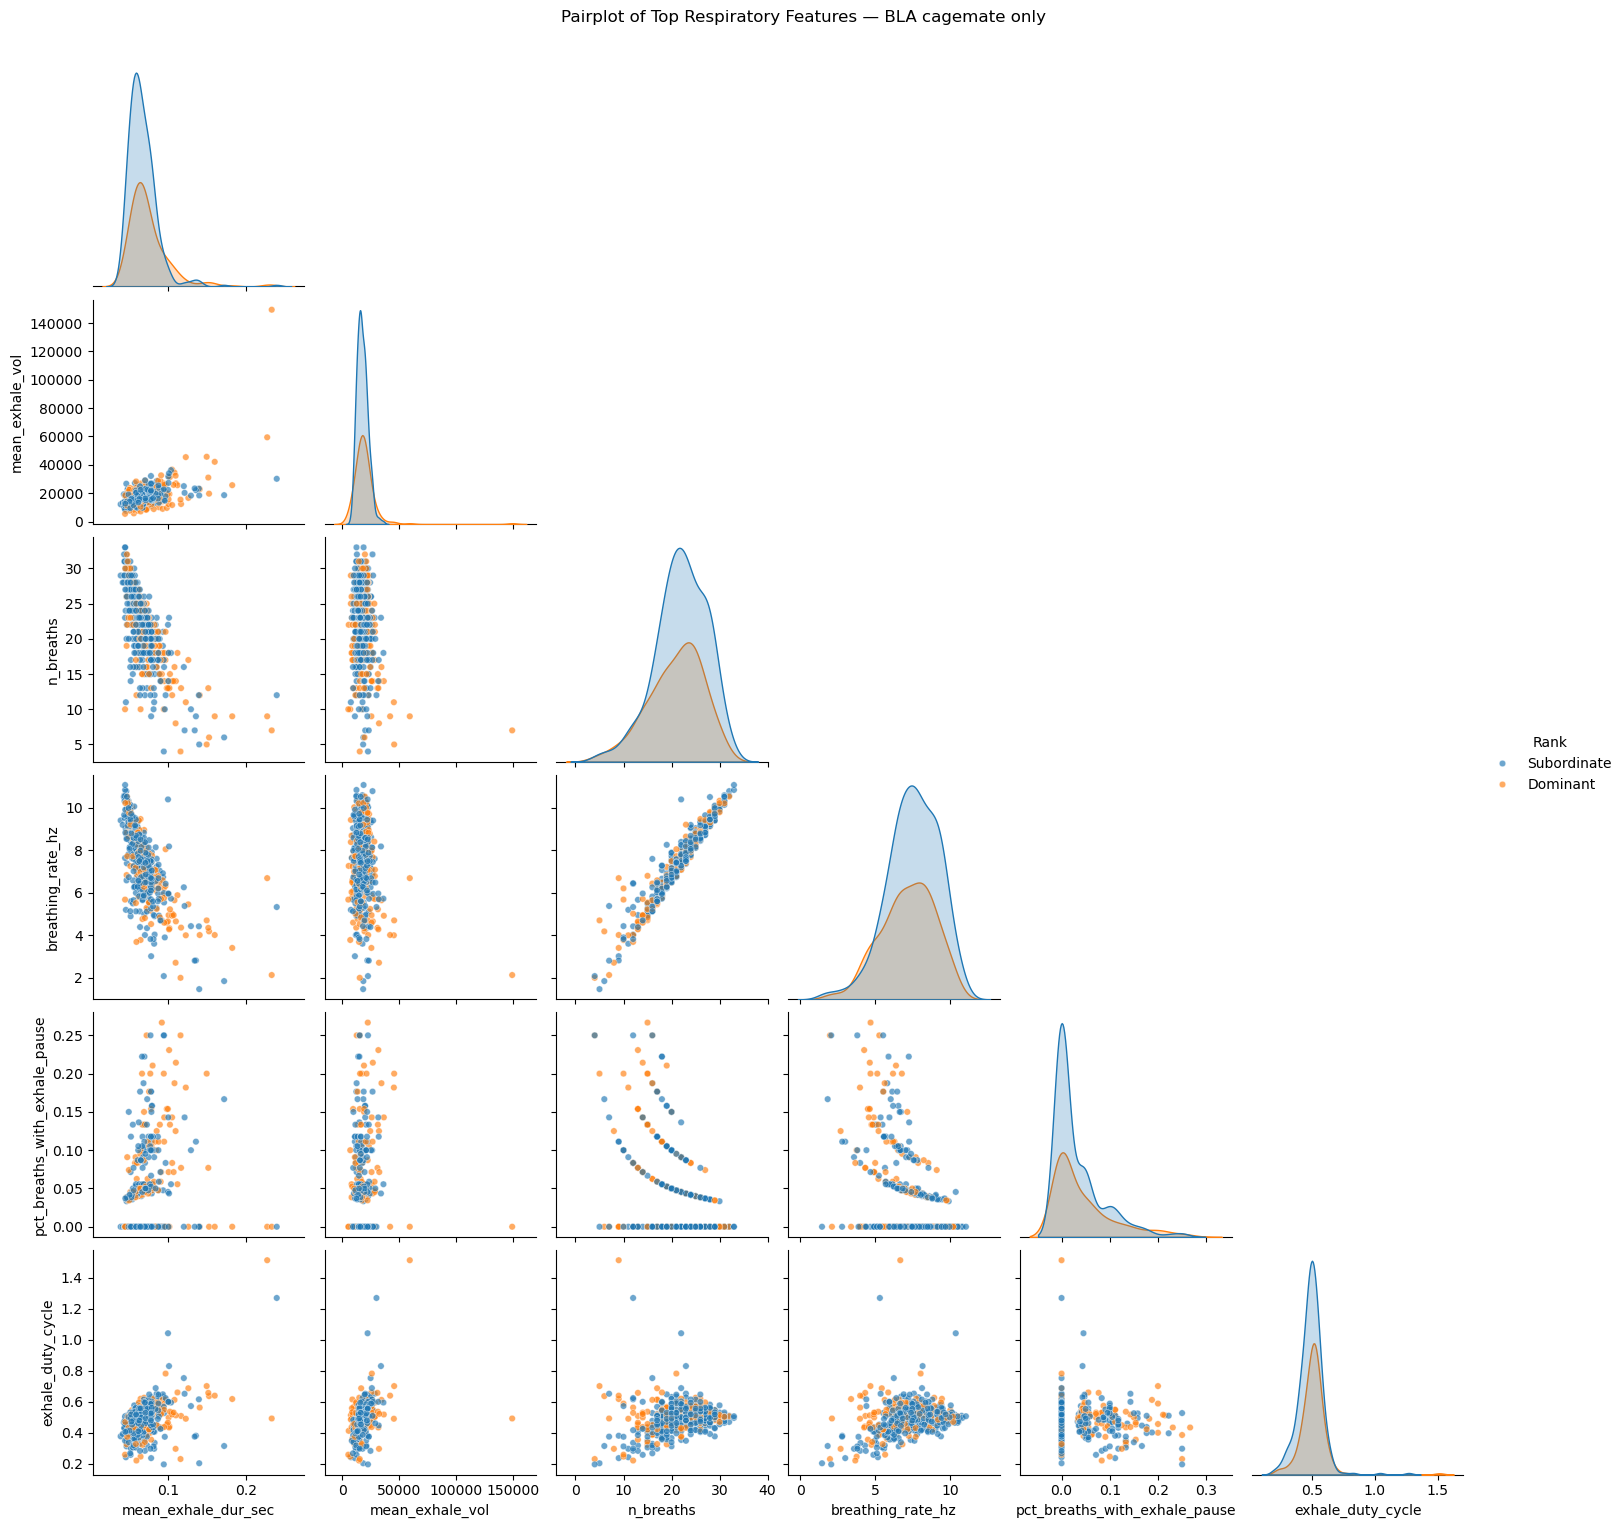

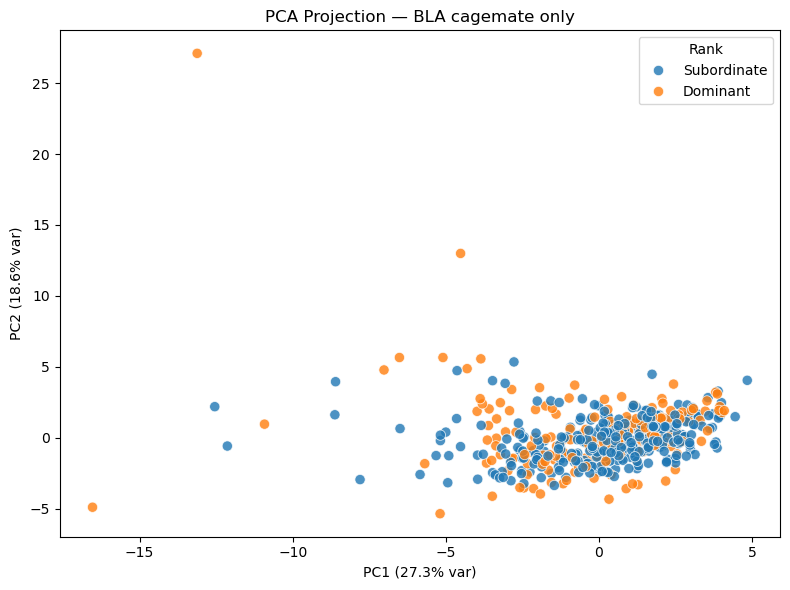

Total variance explained by PC1+PC2: 45.89%

FEATURE INSPECTION — All cohorts
Top features used in pairplot: ['mean_exhale_vol', 'mean_tidal_vol_proxy', 'ventilation_proxy', 'mean_peak_exp_flow', 'mean_peak_insp_flow', 'mean_inhale_vol']


,anova_f_score
mean_exhale_vol,31.642776
mean_tidal_vol_proxy,28.235611
ventilation_proxy,26.769257
mean_peak_exp_flow,24.310790
mean_peak_insp_flow,22.331957
mean_inhale_vol,22.004590
cv_ibi,14.103656
cv_inhale_dur,8.242830
mean_exhale_dur_sec,5.825042
exhale_duty_cycle,5.138825


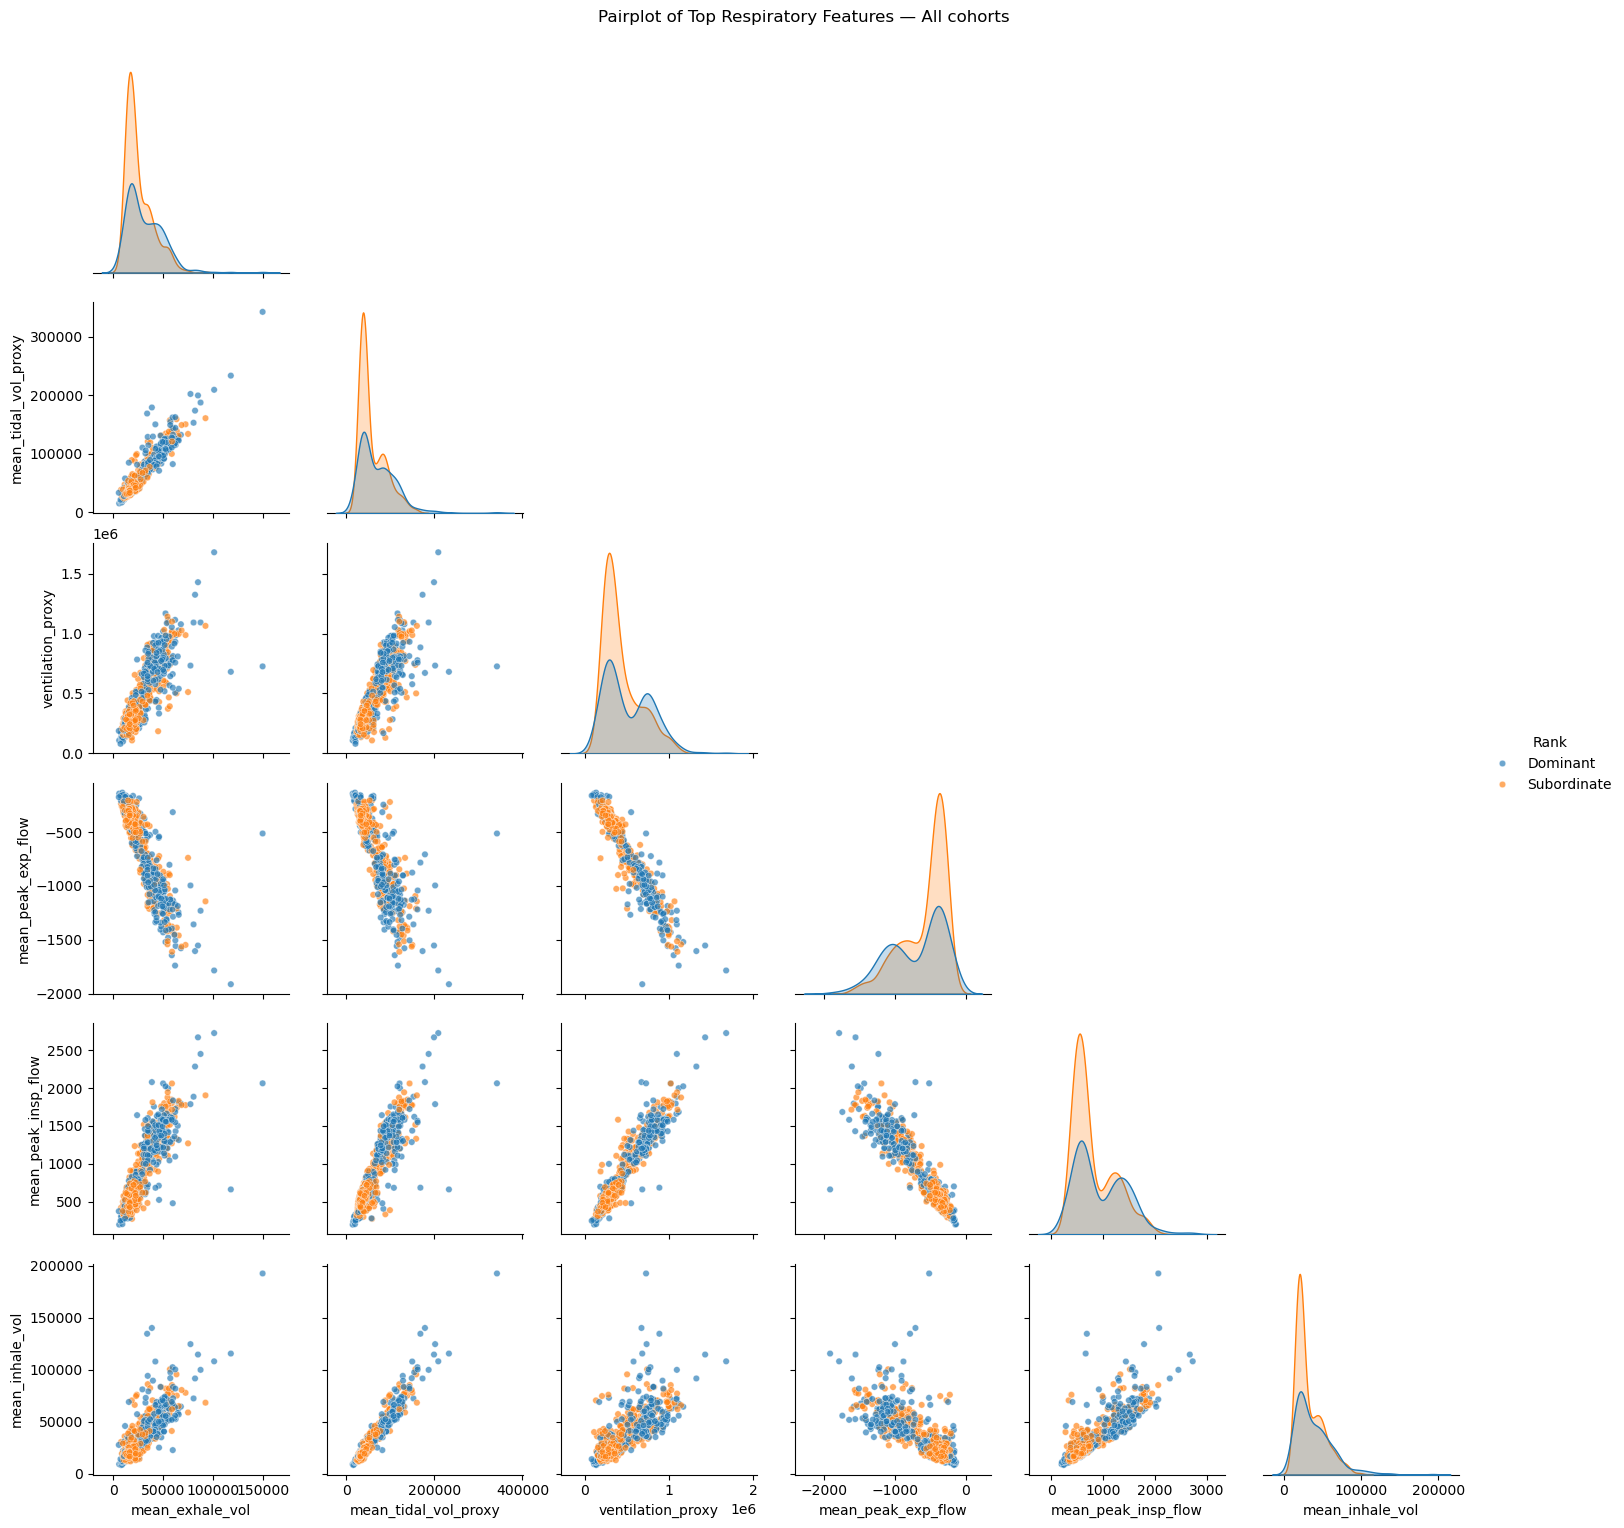

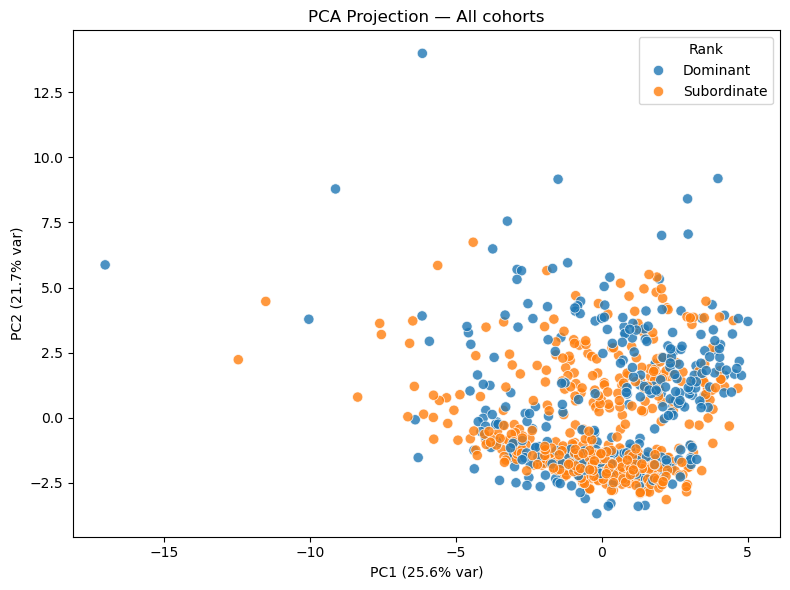

Total variance explained by PC1+PC2: 47.32%


In [72]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import f_classif

N_TOP_FEATURES = 6


def inspect_pairplot_and_pca(prep, dataset_name, n_top_features=N_TOP_FEATURES):
    """Pairplot + PCA for one dataset split."""
    X_local = prep["X"]
    y_local = prep["y"]

    print("\n" + "=" * 80)
    print(f"FEATURE INSPECTION — {dataset_name}")
    print("=" * 80)

    imputer = SimpleImputer(strategy="median")
    X_vis = pd.DataFrame(imputer.fit_transform(X_local), columns=X_local.columns, index=X_local.index)

    f_scores, _ = f_classif(X_vis, y_local)
    feature_rank = pd.Series(f_scores, index=X_vis.columns).sort_values(ascending=False)
    top_features = feature_rank.head(n_top_features).index.tolist()

    print("Top features used in pairplot:", top_features)
    display(feature_rank.head(12).to_frame(name="anova_f_score"))

    pairplot_df = X_vis[top_features].copy()
    pairplot_df[TARGET_COL] = y_local.values

    g = sns.pairplot(
        pairplot_df,
        hue=TARGET_COL,
        corner=True,
        diag_kind="kde",
        plot_kws={"alpha": 0.65, "s": 22},
    )
    g.fig.suptitle(f"Pairplot of Top Respiratory Features — {dataset_name}", y=1.02)
    plt.show()

    X_vis_scaled = pd.DataFrame(
        StandardScaler().fit_transform(X_vis),
        columns=X_vis.columns,
        index=X_vis.index,
    )
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_vis_scaled)

    pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"], index=X_vis.index)
    pca_df[TARGET_COL] = y_local.values

    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue=TARGET_COL, alpha=0.8, s=55)
    plt.title(f"PCA Projection — {dataset_name}")
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% var)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% var)")
    plt.legend(title=TARGET_COL)
    plt.tight_layout()
    plt.show()

    print(
        f"Total variance explained by PC1+PC2: "
        f"{pca.explained_variance_ratio_.sum() * 100:.2f}%"
    )


for dataset_name, prep in dataset_prepared.items():
    inspect_pairplot_and_pca(prep, dataset_name)